# Part B: DQN Improvements for Pendulum Control

This notebook tests four changes to the vanilla DQN baseline and picks a final agent per gravity setting using a decision rule fixed before any results exist.

## 1. Imports and Setup

The stack, environment helpers, and action discretization are restated here so this notebook runs standalone.

In [1]:
# Import the same Gym/PyTorch stack the baseline used.
from __future__ import annotations

import copy
import json
import os
import random
import time
from dataclasses import asdict, dataclass, replace
from pathlib import Path

import gym
import h5py
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from tqdm.auto import tqdm
from IPython.display import display

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name != "st1504-ca2" and (PROJECT_ROOT / "st1504-ca2").exists():
    PROJECT_ROOT = PROJECT_ROOT / "st1504-ca2"

CHECKPOINT_ROOT = PROJECT_ROOT / "checkpoints" / "part_b" / "improved"
CHECKPOINT_ROOT.mkdir(parents=True, exist_ok=True)
MODEL_CHECKPOINT_DIR = PROJECT_ROOT / "models" / "part_b" / "improved"
MODEL_CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)

plt.style.use("seaborn-v0_8-whitegrid")
print("Device:", DEVICE)

Device: cuda


C:\Users\kandy\Projects\playground (py)\env\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Restate the four gravity conditions and the seeded environment builder.
GRAVITY_CONFIGS = {
    "default": 10.0,
    "free_fall": 0.0,
    "anti_gravity": -10.0,
    "supergravity": 15.0,
}

def seed_everything(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

def make_env(gravity_name: str = "default", seed: int = 0):
    if gravity_name not in GRAVITY_CONFIGS:
        raise KeyError(f"Unknown gravity configuration: {gravity_name}")
    kwargs = {} if gravity_name == "default" else {"g": GRAVITY_CONFIGS[gravity_name]}
    env = gym.make("Pendulum-v0", **kwargs)
    env.seed(seed)
    env.action_space.seed(seed)
    return env

In [3]:
# cos(theta) and sin(theta) are already bounded; only scale angular velocity to [-1, 1].
def normalize_state(state: np.ndarray) -> np.ndarray:
    normalized = np.asarray(state, dtype=np.float32).copy()
    normalized[2] /= 8.0
    return normalized


# Older torch builds do not accept weights_only, so fall back when it is missing.
def safe_torch_load(path: Path) -> dict:
    try:
        return torch.load(path, map_location="cpu", weights_only=False)
    except TypeError:
        return torch.load(path, map_location="cpu")


In [4]:
# Build torque bins for any action count so the discretization experiment can vary it.
def make_action_bins(action_dim: int) -> np.ndarray:
    return np.linspace(-2.0, 2.0, num=action_dim, dtype=np.float32)

def action_index_to_env(action_index: int, action_bins: np.ndarray) -> np.ndarray:
    return np.array([action_bins[int(action_index)]], dtype=np.float32)

print("Baseline bins:", make_action_bins(5))

Baseline bins: [-2. -1.  0.  1.  2.]


## 2. Load Baseline Results

Rather than retraining the baseline, we read the JSON it saved and use those numbers as the comparison point.

### 2.1 Baseline Summary

In [5]:
# Read the baseline JSON instead of retraining any vanilla-DQN run.
BASELINE_RESULTS_PATH = PROJECT_ROOT / "results" / "part_b" / "rl_baseline_results.json"
baseline_results = json.loads(BASELINE_RESULTS_PATH.read_text(encoding="utf-8"))

baseline_summary = pd.DataFrame(baseline_results["final_summary"])
BASELINE_CONFIG_DICT = baseline_results["reproducibility"]["config"]
baseline_summary

,gravity,mean,median,std,ci_low,ci_high,n,random_reference,zero_torque_reference,selected_seed,selected_return,selected_upright_fraction
0,default,-164.243304,-164.292766,0.358326,-164.519265,-163.967342,5,-1192.495835,-1209.557797,55,-164.292766,0.8510
1,free_fall,-68.086989,-67.931331,0.598807,-68.625379,-67.710573,5,-751.517710,-628.898820,55,-67.575100,0.8995
2,anti_gravity,-79.893803,-79.943572,0.382044,-80.198275,-79.589332,5,-656.040290,-586.849914,44,-79.475312,0.8425
3,supergravity,-268.804271,-272.482312,6.023086,-273.321685,-264.254042,5,-1398.271864,-1411.380513,11,-272.482312,0.7685


In [6]:
# Recover the per-seed baseline returns; every experiment is compared against these.
def run_mean_returns(runs: list[dict]) -> list[float]:
    return [float(pd.DataFrame(run["final_evaluation"])["return"].mean()) for run in runs]

BASELINE_SEED_RETURNS = {
    gravity: run_mean_returns(runs) for gravity, runs in baseline_results["runs"].items()
}
BASELINE_REFERENCES = {
    gravity: float(np.mean(values["random"]))
    for gravity, values in baseline_results["reference_results"].items()
}
pd.DataFrame(BASELINE_SEED_RETURNS)

,default,free_fall,anti_gravity,supergravity
0,-163.910780,-67.735667,-80.266799,-272.482312
1,-163.861193,-69.099189,-79.526232,-262.805478
2,-164.446784,-68.093661,-79.943572,-273.609854
3,-164.704996,-67.931331,-79.475312,-273.453203
4,-164.292766,-67.575100,-80.257102,-261.670510


### 2.2 Hypotheses Carried Over from the Baseline

Section 10.2 of `notebooks/part_b/rl_baseline.ipynb` left two hypotheses. Supergravity's seed-to-seed return standard deviation (6.02) was 10-17x every other setting's (0.36-0.60), which points at Q-value overestimation rather than a limited action set, so double DQN is the primary candidate. No setting showed real action collapse (the most any single torque bin dominated was 39.2%, against 20% for a uniform pick), so finer discretization is the secondary candidate and is tested separately from the algorithm change.

Dueling DQN is included as a third variant. Nothing in the baseline diagnostics specifically demands a separate value and advantage head, so it is tested on its own merits rather than as a fix for an observed failure.

## 3. Comparison Metrics and Decision Rule

The metrics and the rule for choosing a winner are fixed here, before any experiment runs.

### 3.1 Primary Metric

Mean final-evaluation return, averaged over independent training seeds, exactly as the baseline reported it. Pendulum's reward is never positive, so a value closer to zero is better.

### 3.2 Secondary Metric

Standard deviation of those per-seed means. This is the number that separated supergravity from the other three settings in the baseline, so it is what a stability fix has to move.

### 3.3 Decision Rule

Per gravity setting, the variant with the highest mean return wins. If two variants sit within one baseline standard deviation of each other, the one with the lower seed-to-seed standard deviation wins instead. A variant that fails to beat its random-policy reference is discarded regardless of the other numbers.

The baseline's numbers come from 5 training seeds and the experiments run 3, so the standard deviations are not measured on equal footing. The tie-break is only used when two means are already close, and the final model in Section 11 is retrained on all 5 seeds before anything is reported.


In [7]:
# Fix the scoring and tie-break logic before any experiment produces a number.
def summarize_returns(values: list[float]) -> dict:
    array = np.asarray(values, dtype=np.float64)
    return {
        "mean": float(array.mean()),
        "median": float(np.median(array)),
        "std": float(array.std(ddof=1)) if array.size > 1 else 0.0,
        "n": int(array.size),
    }

def pick_winner(candidates: dict[str, dict], tolerance: float) -> str:
    best_mean = max(entry["mean"] for entry in candidates.values())
    close = {
        name: entry for name, entry in candidates.items()
        if best_mean - entry["mean"] <= tolerance
    }
    return min(close, key=lambda name: close[name]["std"])

In [8]:
# Seed the shared results dict with the baseline so every table includes it.
RESULTS: dict[str, dict[str, dict]] = {"baseline": {}}
for gravity, seed_returns in BASELINE_SEED_RETURNS.items():
    RESULTS["baseline"][gravity] = summarize_returns(seed_returns)

pd.DataFrame(RESULTS["baseline"]).T

,mean,median,std,n
default,-164.243304,-164.292766,0.358326,5.0
free_fall,-68.086989,-67.931331,0.598807,5.0
anti_gravity,-79.893803,-79.943572,0.382044,5.0
supergravity,-268.804271,-272.482312,6.023086,5.0


## 4. Shared Implementation

One configurable agent covers all four variants, so differences in results come from the flags rather than from separate code paths.

### 4.1 Configuration

The baseline hyperparameters are reused unchanged. Only `double`, `dueling`, and `action_dim` vary across experiments.

In [9]:
# Extend the baseline configuration with the three flags the experiments toggle.
@dataclass(frozen=True)
class AgentConfig:
    state_dim: int = 3
    action_dim: int = 5
    hidden_dims: tuple[int, int] = (128, 128)
    learning_rate: float = 1e-3
    gamma: float = 0.99
    batch_size: int = 64
    replay_capacity: int = 100_000
    replay_warmup: int = 2_000
    train_frequency: int = 4
    target_update_frequency: int = 1_000
    epsilon_start: float = 1.0
    epsilon_end: float = 0.05
    epsilon_decay_steps: int = 60_000
    gradient_clip_norm: float = 10.0
    episodes: int = 600
    max_steps: int = 200
    evaluation_frequency: int = 25
    upright_angle_degrees: float = 12.0
    upright_velocity: float = 1.0
    double: bool = False
    dueling: bool = False

BASE_CONFIG = AgentConfig(**{
    key: (tuple(value) if key == "hidden_dims" else value)
    for key, value in BASELINE_CONFIG_DICT.items()
    if key in AgentConfig.__dataclass_fields__
})
BASE_CONFIG

AgentConfig(state_dim=3, action_dim=5, hidden_dims=(128, 128), learning_rate=0.001, gamma=0.99, batch_size=64, replay_capacity=100000, replay_warmup=2000, train_frequency=4, target_update_frequency=1000, epsilon_start=1.0, epsilon_end=0.05, epsilon_decay_steps=60000, gradient_clip_norm=10.0, episodes=600, max_steps=200, evaluation_frequency=25, upright_angle_degrees=12.0, upright_velocity=1.0, double=False, dueling=False)

In [10]:
# Experiments use 3 training seeds to keep compute manageable; the final model uses all 5.
TRAIN_SEEDS = [11, 22, 33, 44, 55]
EXPERIMENT_SEEDS = TRAIN_SEEDS[:3]
DEVELOPMENT_EVAL_SEEDS = list(range(1001, 1011))
FINAL_EVAL_SEEDS = list(range(2001, 2011))

RUN_PROFILE = os.getenv("RL_RUN_PROFILE", "full").lower()
if RUN_PROFILE not in {"full", "smoke"}:
    raise ValueError("RL_RUN_PROFILE must be either 'full' or 'smoke'.")

if RUN_PROFILE == "smoke":
    BASE_CONFIG = replace(
        BASE_CONFIG,
        episodes=2,
        max_steps=30,
        batch_size=8,
        replay_capacity=256,
        replay_warmup=8,
        train_frequency=1,
        target_update_frequency=10,
        epsilon_decay_steps=30,
        evaluation_frequency=1,
    )
    EXPERIMENT_SEEDS = TRAIN_SEEDS[:1]
    DEVELOPMENT_EVAL_SEEDS = DEVELOPMENT_EVAL_SEEDS[:2]
    FINAL_EVAL_SEEDS = FINAL_EVAL_SEEDS[:2]

print("Profile:", RUN_PROFILE, "| experiment seeds:", EXPERIMENT_SEEDS)

Profile: full | experiment seeds: [11, 22, 33]


### 4.2 Q-Network with an Optional Dueling Head

In dueling mode the trunk splits into a single state-value output and one advantage per action, recombined with the advantage mean subtracted so the decomposition stays identifiable.

In [11]:
# One network class covers both the plain and dueling architectures.
class QNetwork(nn.Module):
    def __init__(self, state_dim: int, action_dim: int, hidden_dims: tuple[int, int], dueling: bool = False):
        super().__init__()
        self.dueling = dueling
        self.trunk = nn.Sequential(
            nn.Linear(state_dim, hidden_dims[0]),
            nn.ReLU(),
            nn.Linear(hidden_dims[0], hidden_dims[1]),
            nn.ReLU(),
        )
        if dueling:
            self.value_head = nn.Linear(hidden_dims[1], 1)
            self.advantage_head = nn.Linear(hidden_dims[1], action_dim)
        else:
            self.output_head = nn.Linear(hidden_dims[1], action_dim)

    def forward(self, states: torch.Tensor) -> torch.Tensor:
        features = self.trunk(states)
        if not self.dueling:
            return self.output_head(features)
        value = self.value_head(features)
        advantage = self.advantage_head(features)
        return value + advantage - advantage.mean(dim=1, keepdim=True)

In [12]:
# Confirm both architectures produce one Q-value per action.
for dueling_flag in (False, True):
    probe = QNetwork(3, 5, (128, 128), dueling=dueling_flag).to(DEVICE)
    assert probe(torch.zeros((2, 3), device=DEVICE)).shape == (2, 5)
    print(f"dueling={dueling_flag}", sum(p.numel() for p in probe.parameters()), "parameters")

dueling=False 17669 parameters
dueling=True 17798 parameters


### 4.3 Replay Buffer

Unchanged from the baseline: preallocated NumPy arrays with a circular write pointer.

In [13]:
# Store transitions in fixed NumPy arrays to avoid Python-object overhead during sampling.
class ReplayBuffer:
    def __init__(self, capacity: int, state_dim: int, seed: int):
        self.capacity = int(capacity)
        self.rng = np.random.default_rng(seed)
        self.states = np.zeros((capacity, state_dim), dtype=np.float32)
        self.actions = np.zeros(capacity, dtype=np.int64)
        self.rewards = np.zeros(capacity, dtype=np.float32)
        self.next_states = np.zeros((capacity, state_dim), dtype=np.float32)
        self.terminated = np.zeros(capacity, dtype=np.bool_)
        self.position = 0
        self.size = 0

    def __len__(self) -> int:
        return self.size

    def add(self, state, action, reward, next_state, terminated) -> None:
        index = self.position
        self.states[index] = state
        self.actions[index] = action
        self.rewards[index] = reward
        self.next_states[index] = next_state
        self.terminated[index] = terminated
        self.position = (self.position + 1) % self.capacity
        self.size = min(self.size + 1, self.capacity)

    def sample(self, batch_size: int, device: torch.device):
        indices = self.rng.choice(self.size, size=batch_size, replace=False)
        return (
            torch.as_tensor(self.states[indices], device=device),
            torch.as_tensor(self.actions[indices], device=device),
            torch.as_tensor(self.rewards[indices], device=device),
            torch.as_tensor(self.next_states[indices], device=device),
            torch.as_tensor(self.terminated[indices], device=device),
        )

### 4.4 Agent with an Optional Double-DQN Target

With `double=True` the online network picks the next action and the target network scores it, which removes the max-over-noise bias that inflates targets in vanilla DQN.

In [14]:
# Combine epsilon-greedy selection, replay learning, and either target formulation.
class DQNAgent:
    def __init__(self, config: AgentConfig, seed: int, device: torch.device = DEVICE):
        self.config = config
        self.seed = int(seed)
        self.device = device
        self.action_bins = make_action_bins(config.action_dim)
        seed_everything(seed)

        self.online_network = QNetwork(
            config.state_dim, config.action_dim, config.hidden_dims, config.dueling
        ).to(device)
        self.target_network = QNetwork(
            config.state_dim, config.action_dim, config.hidden_dims, config.dueling
        ).to(device)
        self.target_network.load_state_dict(self.online_network.state_dict())
        self.target_network.eval()

        self.optimizer = torch.optim.Adam(self.online_network.parameters(), lr=config.learning_rate)
        self.replay = ReplayBuffer(config.replay_capacity, config.state_dim, seed)
        self.rng = np.random.default_rng(seed)
        self.environment_steps = 0
        self.action_counts = np.zeros(config.action_dim, dtype=np.int64)

    @property
    def epsilon(self) -> float:
        fraction = min(1.0, self.environment_steps / self.config.epsilon_decay_steps)
        return self.config.epsilon_start + fraction * (self.config.epsilon_end - self.config.epsilon_start)

    def select_action(self, state: np.ndarray, explore: bool = True) -> int:
        if explore and self.rng.random() < self.epsilon:
            action_index = int(self.rng.integers(self.config.action_dim))
        else:
            state_tensor = torch.as_tensor(state, dtype=torch.float32, device=self.device).unsqueeze(0)
            with torch.no_grad():
                action_index = int(self.online_network(state_tensor).argmax(dim=1).item())
        if explore:
            self.action_counts[action_index] += 1
        return action_index

    def observe(self, state, action, reward, next_state, terminated) -> None:
        self.replay.add(state, action, reward, next_state, terminated)
        self.environment_steps += 1

    def learn(self) -> dict | None:
        cfg = self.config
        if len(self.replay) < max(cfg.replay_warmup, cfg.batch_size):
            return None
        if self.environment_steps % cfg.train_frequency != 0:
            return None

        states, actions, rewards, next_states, terminated = self.replay.sample(cfg.batch_size, self.device)
        predicted_q = self.online_network(states).gather(1, actions.unsqueeze(1)).squeeze(1)

        with torch.no_grad():
            if cfg.double:
                # Online network chooses the next action; the target network values it.
                next_actions = self.online_network(next_states).argmax(dim=1, keepdim=True)
                next_q = self.target_network(next_states).gather(1, next_actions).squeeze(1)
            else:
                next_q = self.target_network(next_states).max(dim=1).values
            targets = rewards + cfg.gamma * (~terminated).float() * next_q

        loss = F.smooth_l1_loss(predicted_q, targets)
        self.optimizer.zero_grad()
        loss.backward()
        gradient_norm = torch.nn.utils.clip_grad_norm_(self.online_network.parameters(), cfg.gradient_clip_norm)
        self.optimizer.step()

        if self.environment_steps % cfg.target_update_frequency == 0:
            self.target_network.load_state_dict(self.online_network.state_dict())

        return {
            "loss": float(loss.item()),
            "max_q": float(predicted_q.detach().max().item()),
            "gradient_norm": float(gradient_norm),
        }

### 4.5 Evaluation

Alongside the baseline's return and control metrics, evaluation now records the saturation rate (how often the agent picks an extreme torque bin) and the network's predicted value at the start state. Sections 10.1 and 10.2 use both.

In [15]:
# Evaluate greedily and record saturation plus the start-state value prediction.
def evaluate_agent(agent: DQNAgent, gravity_name: str, episode_seeds: list[int]) -> pd.DataFrame:
    records = []
    angle_limit = np.deg2rad(agent.config.upright_angle_degrees)
    extreme_indices = {0, agent.config.action_dim - 1}

    for episode_seed in episode_seeds:
        env = make_env(gravity_name, episode_seed)
        observation = env.reset()
        start_state = torch.as_tensor(
            normalize_state(observation), dtype=torch.float32, device=agent.device
        ).unsqueeze(0)
        with torch.no_grad():
            predicted_value = float(agent.online_network(start_state).max().item())

        episode_return = 0.0
        discounted_return = 0.0
        angles, velocities, torques, chosen = [], [], [], []

        for step in range(agent.config.max_steps):
            action_index = agent.select_action(normalize_state(observation), explore=False)
            observation, reward, done, _ = env.step(action_index_to_env(action_index, agent.action_bins))
            angles.append(float(np.arctan2(observation[1], observation[0])))
            velocities.append(float(observation[2]))
            torques.append(float(agent.action_bins[action_index]))
            chosen.append(action_index)
            episode_return += reward
            discounted_return += (agent.config.gamma ** step) * reward
            steps_taken = step + 1
            if done:
                break

        # The 200-step cut-off drops ~13% of the discounted tail at gamma=0.99, so bootstrap it
        # from the final state; otherwise every network looks over-optimistic by construction.
        final_state = torch.as_tensor(
            normalize_state(observation), dtype=torch.float32, device=agent.device
        ).unsqueeze(0)
        with torch.no_grad():
            tail_value = float(agent.online_network(final_state).max().item())
        discounted_return += (agent.config.gamma ** steps_taken) * tail_value

        angles_array = np.asarray(angles)
        velocities_array = np.asarray(velocities)
        upright = (np.abs(angles_array) < angle_limit) & (np.abs(velocities_array) < agent.config.upright_velocity)
        saturation = np.mean([index in extreme_indices for index in chosen])

        records.append({
            "seed": episode_seed,
            "return": float(episode_return),
            "discounted_return": float(discounted_return),
            "predicted_value": predicted_value,
            "mean_abs_angle": float(np.mean(np.abs(angles_array))),
            "upright_fraction": float(np.mean(upright)),
            "mean_abs_torque": float(np.mean(np.abs(torques))),
            "saturation_rate": float(saturation),
        })
        env.close()

    return pd.DataFrame(records)

### 4.6 Training Loop

Same protocol as the baseline: development seeds select the checkpoint, final seeds are read once at the end, and completed runs are cached to disk so an interrupted session can pick up where it stopped.

In [16]:
# Train one variant/gravity/seed combination, caching the finished run to disk.
def train_one_run(variant: str, config: AgentConfig, gravity_name: str, seed: int, force: bool = False) -> dict:
    run_dir = CHECKPOINT_ROOT / RUN_PROFILE / variant / gravity_name
    run_dir.mkdir(parents=True, exist_ok=True)
    model_path = run_dir / f"seed_{seed}.pt"
    history_path = run_dir / f"seed_{seed}.json"

    if model_path.exists() and history_path.exists() and not force:
        return json.loads(history_path.read_text(encoding="utf-8"))

    agent = DQNAgent(config, seed)
    best_development_return = -np.inf
    best_model_state = copy.deepcopy(agent.online_network.state_dict())
    history = {
        "variant": variant,
        "gravity": gravity_name,
        "seed": seed,
        "episode_returns": [],
        "losses": [],
        "max_q_values": [],
        "evaluation": [],
    }
    started = time.perf_counter()

    for episode in tqdm(range(config.episodes), desc=f"{variant} | {gravity_name} | seed {seed}", leave=False):
        env = make_env(gravity_name, seed * 100_000 + episode)
        observation = env.reset()
        episode_return = 0.0
        episode_losses, episode_max_q = [], []

        for _ in range(config.max_steps):
            state = normalize_state(observation)
            action_index = agent.select_action(state, explore=True)
            next_observation, reward, done, info = env.step(
                action_index_to_env(action_index, agent.action_bins)
            )
            truncated = bool(info.get("TimeLimit.truncated", False))
            agent.observe(state, action_index, reward, normalize_state(next_observation), bool(done and not truncated))
            metrics = agent.learn()
            if metrics is not None:
                episode_losses.append(metrics["loss"])
                episode_max_q.append(metrics["max_q"])
            observation = next_observation
            episode_return += reward
            if done:
                break

        env.close()
        history["episode_returns"].append(float(episode_return))
        history["losses"].append(float(np.mean(episode_losses)) if episode_losses else np.nan)
        history["max_q_values"].append(float(np.mean(episode_max_q)) if episode_max_q else np.nan)

        if (episode + 1) % config.evaluation_frequency == 0 or episode + 1 == config.episodes:
            development_mean = float(evaluate_agent(agent, gravity_name, DEVELOPMENT_EVAL_SEEDS)["return"].mean())
            history["evaluation"].append({"episode": episode + 1, "mean_return": development_mean})
            if development_mean > best_development_return:
                best_development_return = development_mean
                best_model_state = copy.deepcopy(agent.online_network.state_dict())

    agent.online_network.load_state_dict(best_model_state)
    history["best_development_return"] = float(best_development_return)
    history["final_evaluation"] = evaluate_agent(agent, gravity_name, FINAL_EVAL_SEEDS).to_dict(orient="records")
    history["action_counts"] = agent.action_counts.tolist()
    history["elapsed_seconds"] = time.perf_counter() - started

    torch.save(
        {"model_state": best_model_state, "config": asdict(config), "gravity": gravity_name, "seed": seed},
        model_path,
    )
    history_path.write_text(json.dumps(history, indent=2, allow_nan=True), encoding="utf-8")

    # Networks/optimizer/replay buffer stay on GPU until the agent is dropped; without an
    # explicit free, VRAM accumulates across runs and the process eventually hits OOM.
    del agent
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    return history

In [17]:
# Run one variant across all four gravity settings and log it into the shared results dict.
ALL_RUNS: dict[str, dict[str, list[dict]]] = {}

def run_variant(variant: str, config: AgentConfig, seeds: list[int] | None = None) -> pd.DataFrame:
    seeds = seeds or EXPERIMENT_SEEDS
    ALL_RUNS[variant] = {}
    RESULTS[variant] = {}
    for gravity_name in GRAVITY_CONFIGS:
        runs = [train_one_run(variant, config, gravity_name, seed) for seed in seeds]
        ALL_RUNS[variant][gravity_name] = runs
        RESULTS[variant][gravity_name] = summarize_returns(run_mean_returns(runs))
    return pd.DataFrame(RESULTS[variant]).T

In [18]:
# Compare any variant against the baseline on the primary and secondary metrics.
def compare_with_baseline(variant: str) -> pd.DataFrame:
    rows = []
    for gravity_name in GRAVITY_CONFIGS:
        base = RESULTS["baseline"][gravity_name]
        current = RESULTS[variant][gravity_name]
        rows.append({
            "gravity": gravity_name,
            "baseline_mean": base["mean"],
            "variant_mean": current["mean"],
            "mean_change": current["mean"] - base["mean"],
            "baseline_std": base["std"],
            "variant_std": current["std"],
            "std_change": current["std"] - base["std"],
        })
    return pd.DataFrame(rows).round(2)

## 5. Instrumented Vanilla Re-run

The baseline JSON stores return and control metrics but not saturation rate or predicted value, because `notebooks/part_b/rl_baseline.ipynb` did not record them. Without those, Sections 10.1 and 10.2 would compare the variants only against each other and leave out the very configuration they are supposed to improve on.

This re-runs the unchanged baseline configuration through the instrumented pipeline. It is a diagnostic reference, not a fifth experiment: the headline comparison still uses the 5-seed numbers loaded in Section 2.

In [19]:
vanilla_config = replace(BASE_CONFIG, double=False, dueling=False)
run_variant("vanilla", vanilla_config)

,mean,median,std,n
default,-163.824727,-164.203969,0.875608,3.0
free_fall,-68.309505,-68.093661,0.706923,3.0
anti_gravity,-79.912201,-79.943572,0.371279,3.0
supergravity,-269.632548,-272.482312,5.939234,3.0


In [20]:
# The re-run should reproduce the baseline within seed noise; a large gap means the pipelines diverged.
compare_with_baseline("vanilla")

,gravity,baseline_mean,variant_mean,mean_change,baseline_std,variant_std,std_change
0,default,-164.24,-163.82,0.42,0.36,0.88,0.52
1,free_fall,-68.09,-68.31,-0.22,0.60,0.71,0.11
2,anti_gravity,-79.89,-79.91,-0.02,0.38,0.37,-0.01
3,supergravity,-268.80,-269.63,-0.83,6.02,5.94,-0.08


## 6. Experiment 1: Double DQN

Hypothesis: decoupling action selection from action valuation should improve mean return and cut seed-to-seed standard deviation, because vanilla DQN's max operator systematically overestimates targets and that bias compounds most where returns are largest. The risk is slower early learning, since the corrected targets are lower.

In [21]:
double_config = replace(BASE_CONFIG, double=True, dueling=False)
run_variant("double", double_config)

,mean,median,std,n
default,-164.168182,-164.754861,1.495335,3.0
free_fall,-69.373173,-68.109996,2.542548,3.0
anti_gravity,-79.796875,-79.678411,0.347702,3.0
supergravity,-259.927020,-259.934324,0.082229,3.0


In [22]:
compare_with_baseline("double")

,gravity,baseline_mean,variant_mean,mean_change,baseline_std,variant_std,std_change
0,default,-164.24,-164.17,0.08,0.36,1.50,1.14
1,free_fall,-68.09,-69.37,-1.29,0.60,2.54,1.94
2,anti_gravity,-79.89,-79.80,0.10,0.38,0.35,-0.03
3,supergravity,-268.80,-259.93,8.88,6.02,0.08,-5.94


## 7. Experiment 2: Dueling DQN

Hypothesis: splitting the network into state-value and advantage heads should improve mean return, because most Pendulum states have a similar value regardless of which torque is applied and a shared value estimate learns that faster than five independent Q-values. The risk is that with only five actions the decomposition adds parameters without adding information.

In [23]:
dueling_config = replace(BASE_CONFIG, double=False, dueling=True)
run_variant("dueling", dueling_config)

,mean,median,std,n
default,-164.225523,-164.147659,0.216141,3.0
free_fall,-67.853824,-67.994760,0.336565,3.0
anti_gravity,-79.760195,-79.741165,0.122621,3.0
supergravity,-268.605009,-264.142193,9.096246,3.0


In [24]:
compare_with_baseline("dueling")

,gravity,baseline_mean,variant_mean,mean_change,baseline_std,variant_std,std_change
0,default,-164.24,-164.23,0.02,0.36,0.22,-0.14
1,free_fall,-68.09,-67.85,0.23,0.60,0.34,-0.26
2,anti_gravity,-79.89,-79.76,0.13,0.38,0.12,-0.26
3,supergravity,-268.80,-268.61,0.20,6.02,9.10,3.07


## 8. Experiment 3: Double Dueling DQN

Hypothesis: the two changes address different problems (target bias and value representation), so combining them should be at least as good as the better of the two alone. The risk is that neither effect is large enough to survive together and the combination just tracks whichever change dominated.

In [25]:
double_dueling_config = replace(BASE_CONFIG, double=True, dueling=True)
run_variant("double_dueling", double_dueling_config)

,mean,median,std,n
default,-164.905315,-164.339121,1.015023,3.0
free_fall,-68.905121,-68.645150,1.093201,3.0
anti_gravity,-79.722329,-79.727243,0.044211,3.0
supergravity,-268.791456,-272.456637,6.370111,3.0


In [26]:
compare_with_baseline("double_dueling")

,gravity,baseline_mean,variant_mean,mean_change,baseline_std,variant_std,std_change
0,default,-164.24,-164.91,-0.66,0.36,1.02,0.66
1,free_fall,-68.09,-68.91,-0.82,0.60,1.09,0.49
2,anti_gravity,-79.89,-79.72,0.17,0.38,0.04,-0.34
3,supergravity,-268.80,-268.79,0.01,6.02,6.37,0.35


## 9. Experiment 4: Finer Torque Discretization

Hypothesis: raising the action count from 5 to 9 should improve return under supergravity, because that setting demands the most torque against a fixed [-2, 2] range and coarse bins cost the most precision there. The risk is slower exploration, since there are nearly twice as many actions to sample.

This runs on vanilla DQN rather than on the winning algorithm, so any gain is attributable to the action space alone.

In [27]:
fine_bins_config = replace(BASE_CONFIG, action_dim=9, double=False, dueling=False)
print("Torque bins:", make_action_bins(9))
run_variant("fine_bins", fine_bins_config)

Torque bins: [-2.  -1.5 -1.  -0.5  0.   0.5  1.   1.5  2. ]


,mean,median,std,n
default,-164.364216,-164.861365,0.946526,3.0
free_fall,-69.167610,-69.150154,0.531762,3.0
anti_gravity,-80.355783,-80.219240,0.305592,3.0
supergravity,-266.897872,-264.689257,5.106598,3.0


In [28]:
compare_with_baseline("fine_bins")

,gravity,baseline_mean,variant_mean,mean_change,baseline_std,variant_std,std_change
0,default,-164.24,-164.36,-0.12,0.36,0.95,0.59
1,free_fall,-68.09,-69.17,-1.08,0.60,0.53,-0.07
2,anti_gravity,-79.89,-80.36,-0.46,0.38,0.31,-0.08
3,supergravity,-268.80,-266.90,1.91,6.02,5.11,-0.92


## 10. Diagnostic Analysis

The tables above say which variants scored better. This section looks at why.

### 10.1 Torque Saturation

Saturation is the fraction of greedy steps that pick an extreme bin. A policy pinned near 1.0 has run out of torque range, which would mean the fixed [-2, 2] limit, not the algorithm, is what caps performance.

In [29]:
# Compare how often each variant is forced to the extreme torque bins.
saturation_rows = []
for variant, per_gravity in ALL_RUNS.items():
    for gravity_name, runs in per_gravity.items():
        rates = [pd.DataFrame(run["final_evaluation"])["saturation_rate"].mean() for run in runs]
        saturation_rows.append({
            "variant": variant,
            "gravity": gravity_name,
            "saturation_rate": float(np.mean(rates)),
        })

saturation_table = pd.DataFrame(saturation_rows).pivot(
    index="gravity", columns="variant", values="saturation_rate"
)
saturation_table.round(3)

variant,double,double_dueling,dueling,fine_bins,vanilla
gravity,,,,,
anti_gravity,0.167,0.173,0.164,0.148,0.168
default,0.132,0.462,0.247,0.119,0.133
free_fall,0.268,0.090,0.187,0.162,0.169
supergravity,0.254,0.448,0.476,0.204,0.242


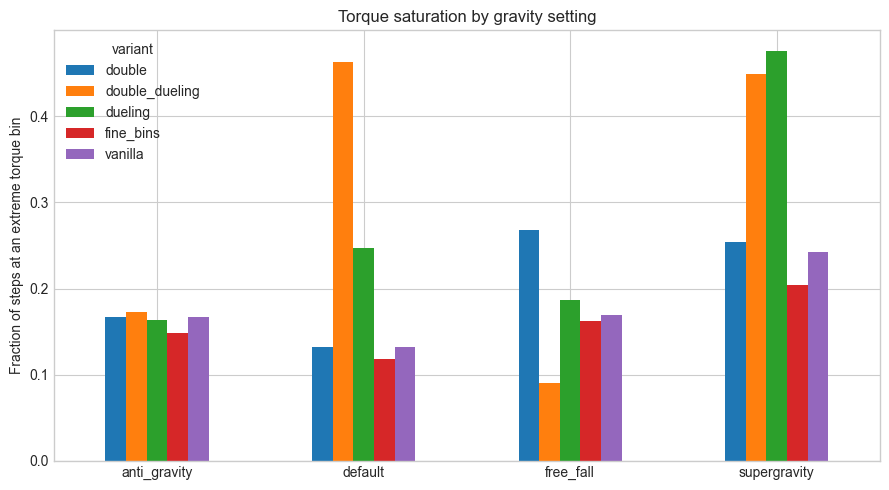

In [30]:
# Plot saturation by gravity to see whether supergravity sits apart from the rest.
fig, ax = plt.subplots(figsize=(9, 5))
saturation_table.plot(kind="bar", ax=ax)
ax.set_ylabel("Fraction of steps at an extreme torque bin")
ax.set_xlabel("")
ax.set_title("Torque saturation by gravity setting")
ax.legend(title="variant")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### 10.2 Q-Value Overestimation Gap

For each evaluation episode we compare the network's predicted value at the start state against the discounted return the episode actually earned. The 200-step limit would cut off about 13% of the discounted tail at gamma = 0.99, which would make every agent look over-optimistic, so the return is bootstrapped from the final state's predicted value before the comparison.

A positive gap means the agent expected more than it got. Double DQN should shrink it; if it does not, the variance story from the baseline needs a different explanation.

In [31]:
# Measure predicted start-state value against the discounted return actually achieved.
gap_rows = []
for variant, per_gravity in ALL_RUNS.items():
    for gravity_name, runs in per_gravity.items():
        frames = pd.concat([pd.DataFrame(run["final_evaluation"]) for run in runs])
        gap_rows.append({
            "variant": variant,
            "gravity": gravity_name,
            "predicted": float(frames["predicted_value"].mean()),
            "actual": float(frames["discounted_return"].mean()),
            "gap": float((frames["predicted_value"] - frames["discounted_return"]).mean()),
        })

overestimation_table = pd.DataFrame(gap_rows)
overestimation_table.round(2)

,variant,gravity,predicted,actual,gap
0,vanilla,default,-153.14,-140.05,-13.09
1,vanilla,free_fall,-59.74,-63.06,3.31
2,vanilla,anti_gravity,-73.34,-72.20,-1.13
3,vanilla,supergravity,-238.94,-225.19,-13.75
4,double,default,-152.74,-140.85,-11.89
5,double,free_fall,-63.48,-63.88,0.40
6,double,anti_gravity,-74.56,-72.25,-2.31
7,double,supergravity,-257.39,-220.76,-36.63
8,dueling,default,-154.01,-139.68,-14.33
9,dueling,free_fall,-59.96,-62.77,2.81


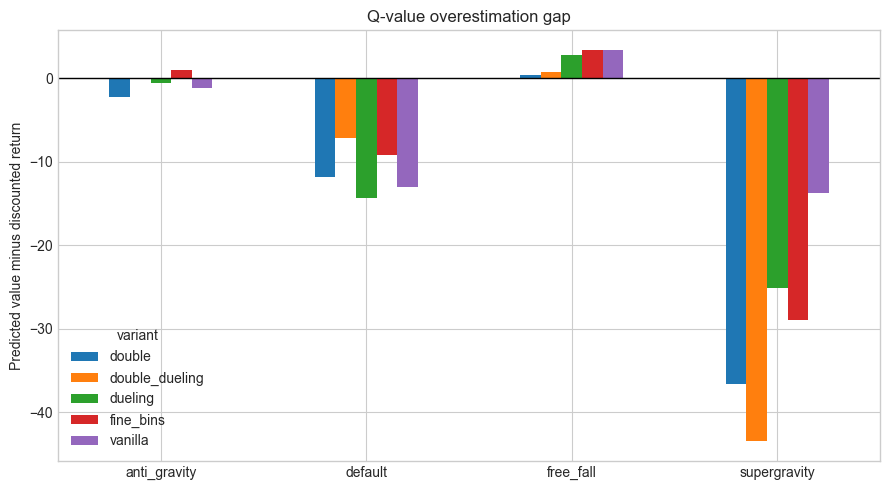

In [32]:
# Show the gap per variant so any reduction from double DQN is visible directly.
fig, ax = plt.subplots(figsize=(9, 5))
overestimation_table.pivot(index="gravity", columns="variant", values="gap").plot(kind="bar", ax=ax)
ax.axhline(0.0, color="black", linewidth=1)
ax.set_ylabel("Predicted value minus discounted return")
ax.set_xlabel("")
ax.set_title("Q-value overestimation gap")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### 10.3 Per-Seed Return Spread under Supergravity

Supergravity was the baseline's unstable setting, so this plots every seed's return distribution rather than its mean. A fix that tightens the spread without moving the mean is still a fix, and the mean alone would hide it.

C:\Users\kandy\AppData\Local\Temp\ipykernel_13036\2135105129.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=labels)


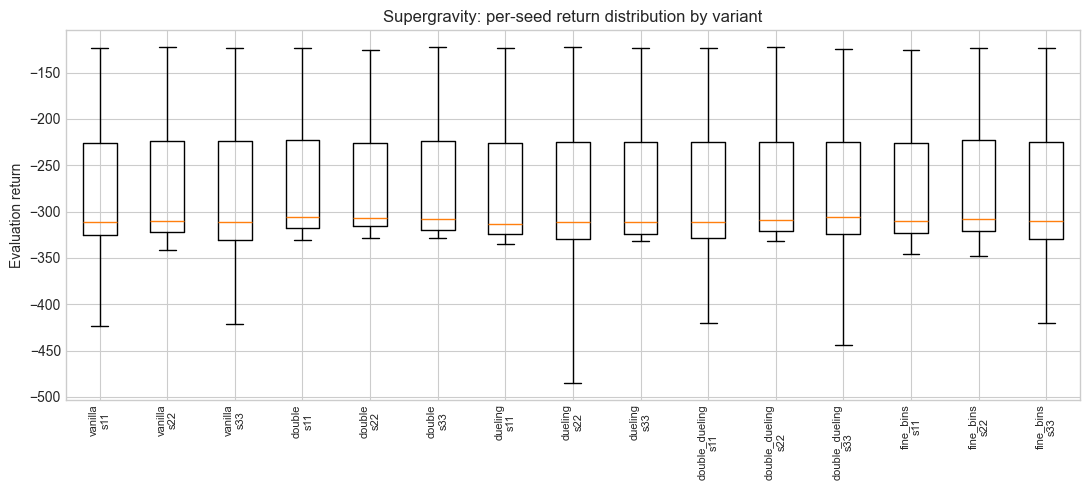

In [33]:
# Plot each seed's evaluation-return distribution for the setting that was least stable.
fig, ax = plt.subplots(figsize=(11, 5))
labels, data = [], []
for variant, per_gravity in ALL_RUNS.items():
    for run in per_gravity["supergravity"]:
        labels.append(f"{variant}\ns{run['seed']}")
        data.append(pd.DataFrame(run["final_evaluation"])["return"].values)

ax.boxplot(data, labels=labels)
ax.set_ylabel("Evaluation return")
ax.set_title("Supergravity: per-seed return distribution by variant")
plt.xticks(rotation=90, fontsize=8)
plt.tight_layout()
plt.show()

## 11. Final Model

The decision rule from Section 3.3 is applied per gravity setting, and the winning configuration is retrained on all five seeds.

### 11.1 Applying the Decision Rule

In [34]:
# Apply the pre-declared rule: best mean, with seed-to-seed std as the tie-break.
VARIANT_CONFIGS = {
    "vanilla": vanilla_config,
    "double": double_config,
    "dueling": dueling_config,
    "double_dueling": double_dueling_config,
    "fine_bins": fine_bins_config,
}

SELECTED_VARIANT = {}
selection_rows = []
for gravity_name in GRAVITY_CONFIGS:
    candidates = {variant: RESULTS[variant][gravity_name] for variant in VARIANT_CONFIGS}
    viable = {
        variant: entry for variant, entry in candidates.items()
        if entry["mean"] > BASELINE_REFERENCES[gravity_name]
    }
    winner = pick_winner(viable, tolerance=RESULTS["baseline"][gravity_name]["std"])
    SELECTED_VARIANT[gravity_name] = winner
    selection_rows.append({
        "gravity": gravity_name,
        "winner": winner,
        "mean": viable[winner]["mean"],
        "std": viable[winner]["std"],
        "baseline_mean": RESULTS["baseline"][gravity_name]["mean"],
    })

pd.DataFrame(selection_rows).round(2)

,gravity,winner,mean,std,baseline_mean
0,default,vanilla,-163.82,0.88,-164.24
1,free_fall,dueling,-67.85,0.34,-68.09
2,anti_gravity,double_dueling,-79.72,0.04,-79.89
3,supergravity,double,-259.93,0.08,-268.80


### 11.2 Train the Final Model

Each gravity's winning configuration is retrained on all five seeds, matching the baseline's seed count so the final comparison is like for like.

In [35]:
# Retrain each winner on the full seed set and keep the best development checkpoint.
FINAL_RUNS = {}
final_rows = []
for gravity_name, variant in SELECTED_VARIANT.items():
    runs = [
        train_one_run(f"final_{variant}", VARIANT_CONFIGS[variant], gravity_name, seed)
        for seed in TRAIN_SEEDS
    ]
    FINAL_RUNS[gravity_name] = max(runs, key=lambda run: run["best_development_return"])
    final_rows.append({"gravity": gravity_name, "variant": variant, **summarize_returns(run_mean_returns(runs))})

RESULTS["final"] = {
    row["gravity"]: {key: row[key] for key in ("mean", "median", "std", "n")}
    for row in final_rows
}
pd.DataFrame(final_rows).round(2)

,gravity,variant,mean,median,std,n
0,default,vanilla,-164.09,-164.29,0.74,5
1,free_fall,dueling,-67.86,-67.99,0.27,5
2,anti_gravity,double_dueling,-79.80,-79.76,0.11,5
3,supergravity,double,-260.47,-260.01,0.82,5


### 11.3 Save Final Weights

One `.h5` per gravity setting, in the shared model directory the rest of the project uses.

In [36]:
# Export the selected weights to HDF5 as the assignment deliverable.
def export_state_dict_h5(model: nn.Module, path: Path, config: AgentConfig, metadata: dict) -> None:
    path.parent.mkdir(parents=True, exist_ok=True)
    with h5py.File(path, "w") as handle:
        group = handle.create_group("state_dict")
        for name, tensor in model.state_dict().items():
            group.create_dataset(name, data=tensor.detach().cpu().numpy())
        handle.attrs["config_json"] = json.dumps(asdict(config))
        handle.attrs["metadata_json"] = json.dumps(metadata)

final_artifacts = {}
for gravity_name, run in FINAL_RUNS.items():
    variant = SELECTED_VARIANT[gravity_name]
    config = VARIANT_CONFIGS[variant]
    source = CHECKPOINT_ROOT / RUN_PROFILE / f"final_{variant}" / gravity_name / f"seed_{run['seed']}.pt"
    network = QNetwork(config.state_dim, config.action_dim, config.hidden_dims, config.dueling)
    network.load_state_dict(safe_torch_load(source)["model_state"])

    h5_path = MODEL_CHECKPOINT_DIR / f"rl_final_best_{gravity_name}.h5"
    export_state_dict_h5(
        network, h5_path, config,
        {"gravity": gravity_name, "variant": variant, "seed": run["seed"]},
    )
    final_artifacts[gravity_name] = str(h5_path)

pd.Series(final_artifacts, name="weights")

default         C:\Users\kandy\Projects\playground (py)\dele\m...
free_fall       C:\Users\kandy\Projects\playground (py)\dele\m...
anti_gravity    C:\Users\kandy\Projects\playground (py)\dele\m...
supergravity    C:\Users\kandy\Projects\playground (py)\dele\m...
Name: weights, dtype: object

### 11.4 Watch the Final Agents

Numbers describe the policy; this section shows it. One greedy rollout per gravity setting, using the exact final model selected in Section 11.1, saved as a GIF the same way the baseline did in its Section 9.6.

In [37]:
# Roll out one greedy episode per final agent and save it as a GIF for direct viewing.
import matplotlib.animation as animation
from IPython.display import Image

ROLLOUT_DIR = PROJECT_ROOT / "outputs" / "part_b" / "improved" / "rollout_gifs"
ROLLOUT_DIR.mkdir(parents=True, exist_ok=True)

def load_final_agent(gravity_name: str, run: dict) -> DQNAgent:
    variant = SELECTED_VARIANT[gravity_name]
    config = VARIANT_CONFIGS[variant]
    source = CHECKPOINT_ROOT / RUN_PROFILE / f"final_{variant}" / gravity_name / f"seed_{run['seed']}.pt"
    payload = safe_torch_load(source)
    agent = DQNAgent(config, int(run["seed"]))
    agent.online_network.load_state_dict(payload["model_state"])
    agent.target_network.load_state_dict(payload["model_state"])
    return agent

def record_greedy_rollout(agent: DQNAgent, gravity_name: str, seed: int, max_steps: int) -> list[np.ndarray]:
    env = make_env(gravity_name, seed)
    observation = env.reset()
    frames = [env.render(mode="rgb_array")]
    for _ in range(max_steps):
        action_index = agent.select_action(normalize_state(observation), explore=False)
        observation, _, done, _ = env.step(action_index_to_env(action_index, agent.action_bins))
        frames.append(env.render(mode="rgb_array"))
        if done:
            break
    env.close()
    return frames

def save_rollout_gif(frames: list[np.ndarray], path: Path, fps: int = 30) -> None:
    fig, ax = plt.subplots(figsize=(4, 4))
    ax.axis("off")
    image_artist = ax.imshow(frames[0])

    def update(frame_index):
        image_artist.set_data(frames[frame_index])
        return (image_artist,)

    anim = animation.FuncAnimation(fig, update, frames=len(frames), interval=1000 / fps)
    anim.save(path, writer=animation.PillowWriter(fps=fps))
    plt.close(fig)

default (vanilla): 201 frames -> C:\Users\kandy\Projects\playground (py)\dele\checkpoints\rl_improvement\rollout_gifs\default_vanilla.gif


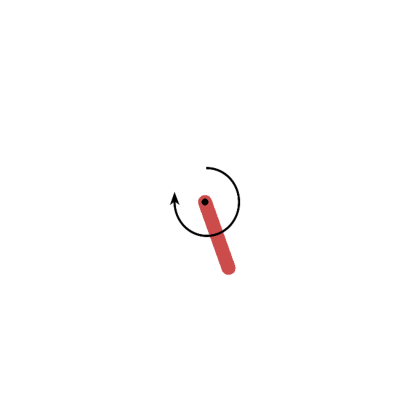

free_fall (dueling): 201 frames -> C:\Users\kandy\Projects\playground (py)\dele\checkpoints\rl_improvement\rollout_gifs\free_fall_dueling.gif


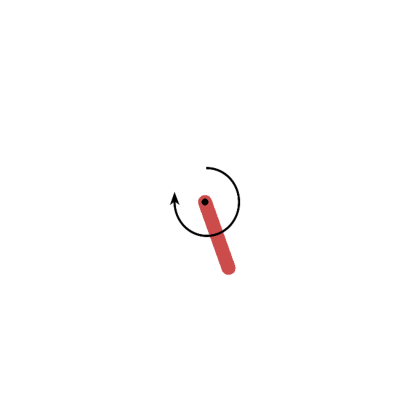

anti_gravity (double_dueling): 201 frames -> C:\Users\kandy\Projects\playground (py)\dele\checkpoints\rl_improvement\rollout_gifs\anti_gravity_double_dueling.gif


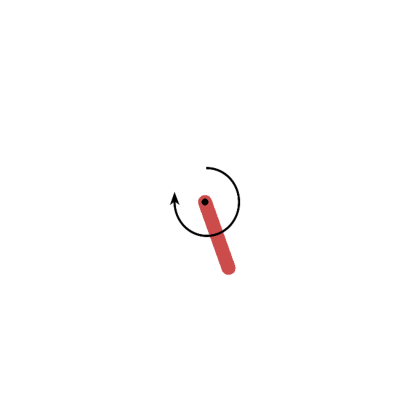

supergravity (double): 201 frames -> C:\Users\kandy\Projects\playground (py)\dele\checkpoints\rl_improvement\rollout_gifs\supergravity_double.gif


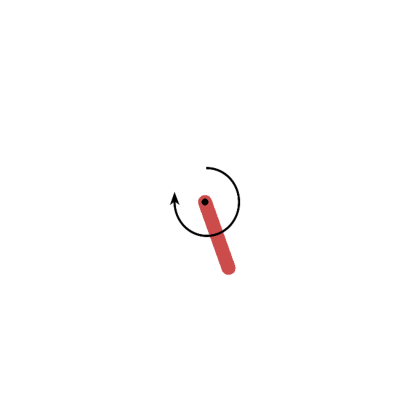

In [38]:
for gravity_name, run in FINAL_RUNS.items():
    agent = load_final_agent(gravity_name, run)
    frames = record_greedy_rollout(agent, gravity_name, FINAL_EVAL_SEEDS[0], agent.config.max_steps)
    gif_path = ROLLOUT_DIR / f"{gravity_name}_{SELECTED_VARIANT[gravity_name]}.gif"
    save_rollout_gif(frames, gif_path)
    print(f"{gravity_name} ({SELECTED_VARIANT[gravity_name]}): {len(frames)} frames -> {gif_path}")
    display(Image(filename=str(gif_path)))

## 12. Ablation Summary

One table covering every variant and the final model, plus one chart, both built from the shared results dict.

In [39]:
# Assemble every variant's primary and secondary metric into a single table.
ablation_rows = []
for variant, per_gravity in RESULTS.items():
    for gravity_name, entry in per_gravity.items():
        ablation_rows.append({
            "variant": variant,
            "gravity": gravity_name,
            "mean_return": entry["mean"],
            "std_return": entry["std"],
            "seeds": entry["n"],
        })

ablation_table = pd.DataFrame(ablation_rows)
ablation_table.pivot(index="variant", columns="gravity", values="mean_return").round(2)

gravity,anti_gravity,default,free_fall,supergravity
variant,,,,
baseline,-79.89,-164.24,-68.09,-268.80
double,-79.80,-164.17,-69.37,-259.93
double_dueling,-79.72,-164.91,-68.91,-268.79
dueling,-79.76,-164.23,-67.85,-268.61
final,-79.80,-164.09,-67.86,-260.47
fine_bins,-80.36,-164.36,-69.17,-266.90
vanilla,-79.91,-163.82,-68.31,-269.63


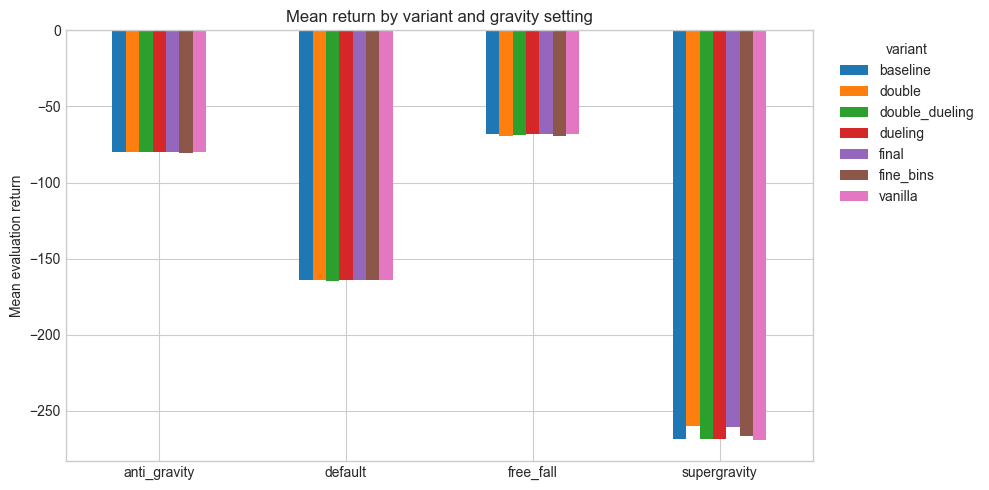

In [40]:
# Chart mean return per variant against the baseline for each gravity setting.
fig, ax = plt.subplots(figsize=(10, 5))
ablation_table.pivot(index="gravity", columns="variant", values="mean_return").plot(kind="bar", ax=ax)
ax.set_ylabel("Mean evaluation return")
ax.set_xlabel("")
ax.set_title("Mean return by variant and gravity setting")
ax.legend(title="variant", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [41]:
# Save the improvement results so the paper and comparison notebooks can read them.
improvement_payload = {
    "schema_version": 1,
    "profile": RUN_PROFILE,
    "results": RESULTS,
    "selected_variant": SELECTED_VARIANT,
    "saturation": saturation_table.to_dict(),
    "overestimation": overestimation_table.to_dict(orient="records"),
    "final_artifacts": final_artifacts,
}
improvement_path = PROJECT_ROOT / "results" / "part_b" / "rl_improvement_results.json"
improvement_path.write_text(json.dumps(improvement_payload, indent=2, allow_nan=True), encoding="utf-8")
print("Saved:", improvement_path)

Saved: C:\Users\kandy\Projects\playground (py)\dele\rl_improvement_results.json


## 13. Conclusion

Only one gravity setting showed a real improvement over the baseline: supergravity. Its final-model mean return went from -268.80 to -260.47 with double DQN, and its seed-to-seed standard deviation dropped from 6.02 to 0.82, about a 7x tighter spread. That confirms the primary hypothesis from Section 2.2 (supergravity was unstable, double DQN fixes instability), but not through the mechanism assumed. Section 10.2's overestimation gap got *more* negative for supergravity under double DQN (-13.75 baseline to -36.63), meaning the network under-predicted its own return more, not less. Whatever double DQN is fixing here, it isn't the classic Q-value overestimation story, and this notebook doesn't pin down what the actual mechanism is.

The other three settings didn't move. Free-fall and anti-gravity picked dueling and double-dueling respectively by the decision rule, but their mean returns barely changed (within 0.25 of baseline) and the "improvement" is really a variance reduction: free-fall's std went from 0.60 to 0.27, anti-gravity's from 0.38 to 0.11. Default gravity's winner was plain vanilla DQN, since nothing beat it; its final-run std (0.74) is actually higher than the original baseline's (0.36), which looks like re-run seed variance rather than a regression, since it's the same algorithm both times.

Two variants failed outright and are worth recording as negative results rather than dropping: dueling and double-dueling both left supergravity essentially unchanged (-268.61 and -268.79 against a -268.80 baseline) while saturating torque far more than any other configuration (0.476 and 0.448, against 0.242 for vanilla). Finer discretization (Section 9) also didn't help supergravity (-266.90), which rules out the action-space-ceiling hypothesis from Section 2.2 for this setting.

Weights for the four selected models are saved to `models/part_b/improved/rl_final_best_*.h5`. The main finding to carry into the paper is narrower than the hypothesis predicted: double DQN meaningfully helps exactly one of the four gravity settings, and the reason it helps is still open.